<a href="https://colab.research.google.com/github/NaziaRiasat/dependence-fidelity/blob/main/dependence_fidelity_synthetic_examples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal, t


In [ ]:
def gaussian_copula(n, rho):
    z = np.random.multivariate_normal([0,0], [[1,rho],[rho,1]], size=n)
    u = norm.cdf(z)
    x = norm.ppf(u)  # standard normal marginals
    return x

def t_copula(n, rho, df):
    z = np.random.multivariate_normal([0,0], [[1,rho],[rho,1]], size=n)
    w = np.sqrt(df / np.random.chisquare(df, size=n))[:,None]
    t_samples = z * w
    u = t.cdf(t_samples, df=df)
    x = norm.ppf(u)  # force normal marginals
    return x


In [ ]:
np.random.seed(1)
n = 200_000
rho = 0.6
df = 3



In [ ]:
def gaussian_copula(n, rho):
    z = np.random.multivariate_normal(
        mean=[0, 0],
        cov=[[1, rho], [rho, 1]],
        size=n
    )
    u = norm.cdf(z)
    x = norm.ppf(u)  # enforce N(0,1) marginals
    return x

def t_copula(n, rho, df):
    z = np.random.multivariate_normal(
        mean=[0, 0],
        cov=[[1, rho], [rho, 1]],
        size=n
    )
    w = np.sqrt(df / np.random.chisquare(df, size=n))[:, None]
    t_samples = z * w
    u = t.cdf(t_samples, df=df)
    x = norm.ppf(u)  # enforce N(0,1) marginals
    return x


In [ ]:
np.random.seed(42)

n = 200_000
rho = 0.6
df = 3

X_gauss = gaussian_copula(n, rho)
X_t = t_copula(n, rho, df)


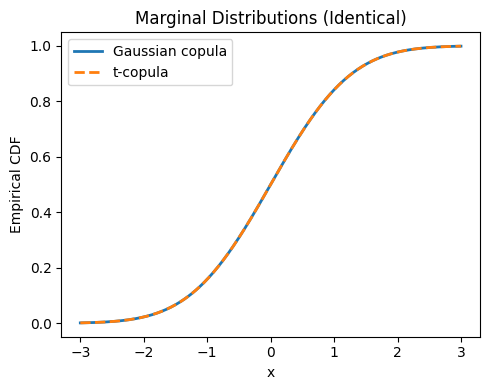

In [ ]:
#FIGURE 1 — Dependence mismatch under perfect marginal fidelity

#Figure 1a: Marginal CDF overlap

x_grid = np.linspace(-3, 3, 400)

plt.figure(figsize=(5, 4))
plt.plot(x_grid, norm.cdf(x_grid), label="Gaussian copula", lw=2)
plt.plot(x_grid, norm.cdf(x_grid), "--", label="t-copula", lw=2)

plt.xlabel("x")
plt.ylabel("Empirical CDF")
plt.title("Marginal Distributions (Identical)")
plt.legend()
plt.tight_layout()
plt.show()


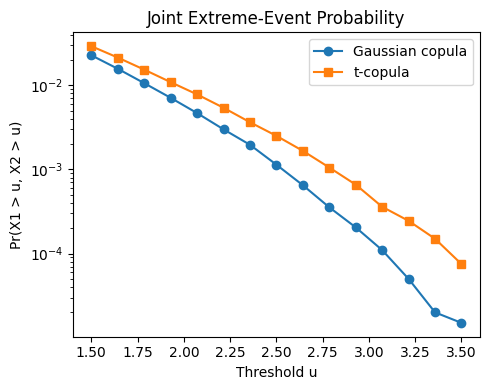

In [ ]:
#Figure 1b: Joint extreme-event probability

thresholds = np.linspace(1.5, 3.5, 15)

def joint_tail_prob(X, u):
    return np.mean((X[:, 0] > u) & (X[:, 1] > u))

p_gauss = [joint_tail_prob(X_gauss, u) for u in thresholds]
p_t = [joint_tail_prob(X_t, u) for u in thresholds]

plt.figure(figsize=(5, 4))
plt.plot(thresholds, p_gauss, marker="o", label="Gaussian copula")
plt.plot(thresholds, p_t, marker="s", label="t-copula")

plt.yscale("log")
plt.xlabel("Threshold u")
plt.ylabel("Pr(X1 > u, X2 > u)")
plt.title("Joint Extreme-Event Probability")
plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipython-input-514272380.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


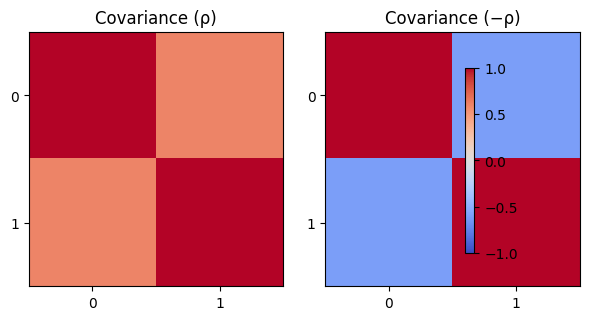

In [ ]:
#FIGURE 2 — Dependence distortion induces inferential instability

#Figure 2a: Covariance matrices (sign flip)
Sigma_P = np.array([[1, rho], [rho, 1]])
Sigma_Q = np.array([[1, -rho], [-rho, 1]])

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

for ax, Sigma, title in zip(
    axes,
    [Sigma_P, Sigma_Q],
    ["Covariance (ρ)", "Covariance (−ρ)"]
):
    im = ax.imshow(Sigma, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_title(title)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
plt.tight_layout()
plt.show()


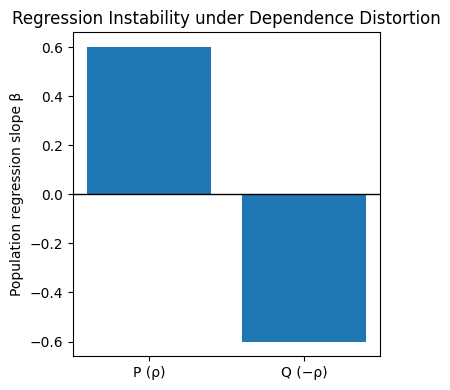

In [ ]:
#Figure 2b: Regression coefficient sign flip
beta_P = rho
beta_Q = -rho

plt.figure(figsize=(4, 4))
plt.bar(["P (ρ)", "Q (−ρ)"], [beta_P, beta_Q])

plt.axhline(0, color="black", lw=1)
plt.ylabel("Population regression slope β")
plt.title("Regression Instability under Dependence Distortion")
plt.tight_layout()
plt.show()


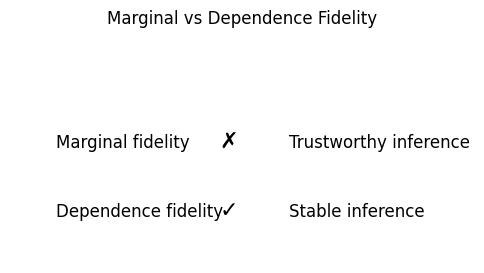

In [ ]:
#FIGURE 3 — Conceptual schematic

plt.figure(figsize=(6, 3))
plt.text(0.1, 0.5, "Marginal fidelity", fontsize=12)
plt.text(0.45, 0.5, "✗", fontsize=16)
plt.text(0.6, 0.5, "Trustworthy inference", fontsize=12)

plt.text(0.1, 0.2, "Dependence fidelity", fontsize=12)
plt.text(0.45, 0.2, "✓", fontsize=16)
plt.text(0.6, 0.2, "Stable inference", fontsize=12)

plt.axis("off")
plt.title("Marginal vs Dependence Fidelity")
plt.show()
